In [9]:

import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import pandas as pd
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, classification_report

# Import from our custom modules in the src/ folder
from NN.features import clean_and_engineer, prepare_model_data
from NN.dataset import FinancialNeedsDataset
from NN.model import MultiTaskNeedsMLP
from NN.train import train_multitask_model

print("Setup complete. Custom modules loaded successfully.")






Setup complete. Custom modules loaded successfully.


In [10]:

# 1. Load raw data from the Excel file (specifically the 'Needs' sheet)
df = pd.read_excel('Dataset2_Needs.xls', sheet_name='Needs')

# 2. Run feature engineering and data cleaning
df_engineered = clean_and_engineer(df)

# 3. Split data and apply scikit-learn scaling strictly on train to avoid leakage
X_train, X_val, y_train, y_val, feature_cols = prepare_model_data(df_engineered)

print(f"Training features shape: {X_train.shape}")
print(f"Validation features shape: {X_val.shape}")

# Define which features are continuous (safe for noise) vs binary
binary_features = ['Gender', 'LifeStage_working', 'LifeStage_retired']
continuous_mask = [True if col not in binary_features else False for col in feature_cols]

# 4. Create PyTorch Datasets (Applying tabular augmentation ONLY to training)
train_dataset = FinancialNeedsDataset(X_train, y_train, augment=True, noise_std=0.05, continuous_mask=continuous_mask)
val_dataset = FinancialNeedsDataset(X_val, y_val, augment=False)

# 5. Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

print("DataLoaders ready.")

Training features shape: (4000, 20)
Validation features shape: (1000, 20)
DataLoaders ready.


In [11]:
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, f1_score
import time

print("--- EVALUATING SVM BASELINE ON ENGINEERED FEATURES ---\n")

def evaluate_svm_baseline(X_tr, y_tr, X_v, y_v, target_name):
    print(f"Target: {target_name}")
    print("="*40)
    
    start_time = time.time()
    
    # Support Vector Machine
    # class_weight='balanced' is crucial for the imbalanced Income target
    svm_model = SVC(probability=True, random_state=42, class_weight='balanced')
    svm_model.fit(X_tr, y_tr)
    
    svm_preds = svm_model.predict_proba(X_v)[:, 1]
    svm_pred_class = svm_model.predict(X_v)
    
    auc = roc_auc_score(y_v, svm_preds)
    f1 = f1_score(y_v, svm_pred_class)
    
    print(f"SVM ROC-AUC     : {auc:.4f}")
    print(f"SVM F1-Score    : {f1:.4f}")
    print(f"Training Time   : {time.time() - start_time:.2f} seconds\n")
    
    return svm_model

# Evaluate Income
svm_inc = evaluate_svm_baseline(
    X_train, y_train['IncomeInvestment'], 
    X_val, y_val['IncomeInvestment'], 
    "Income Investment"
)

# Evaluate Accumulation
svm_acc = evaluate_svm_baseline(
    X_train, y_train['AccumulationInvestment'], 
    X_val, y_val['AccumulationInvestment'], 
    "Accumulation Investment"
)

--- EVALUATING SVM BASELINE ON ENGINEERED FEATURES ---

Target: Income Investment
SVM ROC-AUC     : 0.7837
SVM F1-Score    : 0.6915
Training Time   : 3.10 seconds

Target: Accumulation Investment
SVM ROC-AUC     : 0.8369
SVM F1-Score    : 0.7710
Training Time   : 2.58 seconds



In [12]:
import torch.nn as nn
import torch.nn.functional as F

# 1. Define the Single-Task Architecture (Exact same capacity as one branch of the Multi-Task model)
class SingleTaskMLP(nn.Module):
    def __init__(self, in_dim, trunk=(64, 32), head=(16,), p=0.25):
        super().__init__()
        layers, d = [], in_dim
        
        # Trunk
        for h in trunk:
            layers += [nn.Linear(d, h), nn.BatchNorm1d(h), nn.GELU(), nn.Dropout(p)]
            d = h
            
        # Head
        for h in head:
            layers += [nn.Linear(d, h), nn.GELU(), nn.Dropout(p)]
            d = h
            
        layers += [nn.Linear(d, 1)] # Single output
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)

# 2. Quick Training Loop for Single-Task
def train_single_task(target_idx, train_loader, val_loader, in_dim, pos_weight, epochs=40):
    model = SingleTaskMLP(in_dim=in_dim)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    
    best_auc = 0
    for epoch in range(epochs):
        model.train()
        for X_batch, y_inc, y_acc in train_loader:
            optimizer.zero_grad()
            
            # Select target: target_idx 0 is Income, 1 is Accumulation
            targets = y_inc if target_idx == 0 else y_acc
            logits = model(X_batch)
            
            loss = F.binary_cross_entropy_with_logits(logits, targets, pos_weight=pos_weight)
            loss.backward()
            optimizer.step()
            
        # Validation
        model.eval()
        val_preds, val_targs = [], []
        with torch.no_grad():
            for X_batch, y_inc, y_acc in val_loader:
                targets = y_inc if target_idx == 0 else y_acc
                logits = model(X_batch)
                val_preds.extend(torch.sigmoid(logits).numpy())
                val_targs.extend(targets.numpy())
                
        auc = roc_auc_score(val_targs, val_preds)
        if auc > best_auc:
            best_auc = auc
            
    return best_auc

# 3. Execute Single-Task Training
print("--- EVALUATING SINGLE-TASK NEURAL NETWORKS ---")

# Weights (Calculated dynamically)
w_inc = torch.tensor((len(y_train) - y_train['IncomeInvestment'].sum()) / y_train['IncomeInvestment'].sum())
w_acc = torch.tensor((len(y_train) - y_train['AccumulationInvestment'].sum()) / y_train['AccumulationInvestment'].sum())

auc_inc_single = train_single_task(0, train_loader, val_loader, len(feature_cols), w_inc)
auc_acc_single = train_single_task(1, train_loader, val_loader, len(feature_cols), w_acc)

print(f"Single-Task NN | Income ROC-AUC       : {auc_inc_single:.4f}")
print(f"Single-Task NN | Accumulation ROC-AUC : {auc_acc_single:.4f}\n")

--- EVALUATING SINGLE-TASK NEURAL NETWORKS ---
Single-Task NN | Income ROC-AUC       : 0.7996
Single-Task NN | Accumulation ROC-AUC : 0.8497



In [13]:
# --- Handling Imbalance ---
# Calculate positive weights for Binary Cross Entropy
num_acc_pos = y_train['AccumulationInvestment'].sum()
w_a = torch.tensor((len(y_train) - num_acc_pos) / num_acc_pos, dtype=torch.float32)

num_inc_pos = y_train['IncomeInvestment'].sum()
w_i = torch.tensor((len(y_train) - num_inc_pos) / num_inc_pos, dtype=torch.float32)

print(f"Class Weight Accumulation: {w_a.item():.2f}")
print(f"Class Weight Income: {w_i.item():.2f}")

# --- The "Business Reality" Prior ---
# Empirical Joint Distribution: [Neither, IncomeOnly, AccumOnly, Both]
# Values from the business case dataset exploration
joint_prior = torch.tensor([0.303, 0.184, 0.314, 0.200], dtype=torch.float32)

# --- Initialize Model ---
model = MultiTaskNeedsMLP(in_dim=len(feature_cols), trunk=(64, 32), head=(16,), p=0.25)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

print("\nModel architecture ready:")
print(model)

Class Weight Accumulation: 0.95
Class Weight Income: 1.61

Model architecture ready:
MultiTaskNeedsMLP(
  (trunk): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.25, inplace=False)
  )
  (head_accum): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=16, out_features=1, bias=True)
  )
  (head_income): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.25, inplace=False)
    (3): Linear(in_features=16, out

In [14]:
print("Starting Multi-Task Training...\n")

best_model, val_auc = train_multitask_model(
    model=model, 
    train_loader=train_loader, 
    val_loader=val_loader, 
    optimizer=optimizer, 
    w_a=w_a, 
    w_i=w_i, 
    joint_prior=joint_prior, 
    epochs=150, 
    patience=20, 
    lam=0.15  # Strength of the joint-distribution penalty
)

print(f"\nTraining Complete! Best Validation AUC (Mean): {val_auc:.4f}")

Starting Multi-Task Training...

Epoch 000 | Loss: 1.4144 | ROC-AUC (Acc/Inc): 0.725/0.770 | PR-AUC (Acc/Inc): 0.728/0.765
Epoch 010 | Loss: 1.1614 | ROC-AUC (Acc/Inc): 0.834/0.785 | PR-AUC (Acc/Inc): 0.877/0.778
Epoch 020 | Loss: 1.1364 | ROC-AUC (Acc/Inc): 0.845/0.789 | PR-AUC (Acc/Inc): 0.886/0.782
Epoch 030 | Loss: 1.1264 | ROC-AUC (Acc/Inc): 0.849/0.790 | PR-AUC (Acc/Inc): 0.889/0.785
Epoch 040 | Loss: 1.1171 | ROC-AUC (Acc/Inc): 0.855/0.795 | PR-AUC (Acc/Inc): 0.892/0.792
Epoch 050 | Loss: 1.1120 | ROC-AUC (Acc/Inc): 0.852/0.796 | PR-AUC (Acc/Inc): 0.892/0.791
Epoch 060 | Loss: 1.0929 | ROC-AUC (Acc/Inc): 0.853/0.798 | PR-AUC (Acc/Inc): 0.892/0.794
Epoch 070 | Loss: 1.0982 | ROC-AUC (Acc/Inc): 0.857/0.796 | PR-AUC (Acc/Inc): 0.894/0.792

Early stopping triggered at epoch 73. Restoring best weights.

Training Complete! Best Validation AUC (Mean): 0.8439


In [15]:
# Set model to evaluation mode
model.eval()

val_preds_acc, val_preds_inc = [], []
val_targs_acc, val_targs_inc = [], []

# Get predictions for the validation set
with torch.no_grad():
    for X_batch, y_inc, y_acc in val_loader:
        logits_acc, logits_inc = model(X_batch)
        val_preds_acc.extend(torch.sigmoid(logits_acc).numpy())
        val_preds_inc.extend(torch.sigmoid(logits_inc).numpy())
        val_targs_acc.extend(y_acc.numpy())
        val_targs_inc.extend(y_inc.numpy())

# Convert probabilities to binary predictions (using 0.5 threshold for now)
pred_classes_acc = [1 if p > 0.5 else 0 for p in val_preds_acc]
pred_classes_inc = [1 if p > 0.5 else 0 for p in val_preds_inc]

print("--- ACCUMULATION INVESTMENT ---")
print(f"ROC-AUC: {roc_auc_score(val_targs_acc, val_preds_acc):.4f}")
print(classification_report(val_targs_acc, pred_classes_acc))

print("\n--- INCOME INVESTMENT ---")
print(f"ROC-AUC: {roc_auc_score(val_targs_inc, val_preds_inc):.4f}")
print(classification_report(val_targs_inc, pred_classes_inc))

--- ACCUMULATION INVESTMENT ---
ROC-AUC: 0.8531
              precision    recall  f1-score   support

         0.0       0.74      0.91      0.82       487
         1.0       0.90      0.70      0.78       513

    accuracy                           0.80      1000
   macro avg       0.82      0.81      0.80      1000
weighted avg       0.82      0.80      0.80      1000


--- INCOME INVESTMENT ---
ROC-AUC: 0.8005
              precision    recall  f1-score   support

         0.0       0.79      0.93      0.85       617
         1.0       0.83      0.60      0.70       383

    accuracy                           0.80      1000
   macro avg       0.81      0.76      0.78      1000
weighted avg       0.81      0.80      0.79      1000



In [16]:
import pandas as pd
import numpy as np
import torch

print("--- NEXT BEST ACTION: PROPENSITY + COMPLIANCE LAYER ---\n")

products_df = pd.read_excel('Dataset2_Needs.xls', sheet_name='Products')
model.eval()

# Get predictions for ALL clients
X_all = clean_and_engineer(df)
X_all_scaled = X_all[feature_cols].copy()

# Note: In a true prod env, we'd apply the exact 'qt' and 'rs' scalers fitted on train data here.
# For the sake of the notebook, we are using the scaled DataLoader to extract predictions.
all_dataset = FinancialNeedsDataset(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]), augment=False)
all_loader = DataLoader(all_dataset, batch_size=512, shuffle=False)

all_preds_acc, all_preds_inc = [], []
with torch.no_grad():
    for X_batch, _, _ in all_loader:
        logits_acc, logits_inc = model(X_batch)
        all_preds_acc.extend(torch.sigmoid(logits_acc).numpy())
        all_preds_inc.extend(torch.sigmoid(logits_inc).numpy())

original_indices = pd.concat([X_train, X_val]).index
client_risks = df.loc[original_indices, 'RiskPropensity'].values
client_ids = df.loc[original_indices, 'ID'].values if 'ID' in df.columns else original_indices

recommendations = []

for i in range(len(client_ids)):
    c_id = client_ids[i]
    p_acc = all_preds_acc[i]
    p_inc = all_preds_inc[i]
    c_risk = client_risks[i]
    
    eligible_products = []
    
    # ---------------------------------------------------------
    # LAYER 1: HARD RULES & ELIGIBILITY (Regulatory Compliance)
    # ---------------------------------------------------------
    for _, product in products_df.iterrows():
        # MiFID II Rule: Product risk cannot exceed client risk propensity 
        # (We allow a tiny 0.05 buffer for edge cases)
        if product['Risk'] > (c_risk + 0.05):
            continue # Discard! Client is not eligible for this product
            
        eligible_products.append(product)
        
    # ---------------------------------------------------------
    # LAYER 2: PROPENSITY RANKING (The ML Layer)
    # ---------------------------------------------------------
    client_scores = []
    for product in eligible_products:
        prod_id = product['IDProduct']
        prod_type = product['Type']
        
        # Base ML Propensity
        score = p_acc if prod_type == 1.0 else p_inc
        client_scores.append((prod_id, score))
    
    # Sort eligible products by ML score
    client_scores.sort(key=lambda x: x[1], reverse=True)
    
    # Handle cases where the client's risk is so low, no products are eligible
    if len(client_scores) == 0:
        recommendations.append({'ClientID': c_id, 'Rec_1': 'None Eligible', 'Rec_2': 'None Eligible', 'Rec_3': 'None Eligible'})
    else:
        # Pad with 'None' if there are fewer than 3 eligible products
        client_scores += [(None, 0)] * (3 - len(client_scores))
        recommendations.append({
            'ClientID': c_id,
            'Rec_1': client_scores[0][0],
            'Rec_2': client_scores[1][0],
            'Rec_3': client_scores[2][0]
        })

recs_df = pd.DataFrame(recommendations)
print("Top 3 Compliant Recommendations for First 5 Clients:")
display(recs_df.head())

--- NEXT BEST ACTION: PROPENSITY + COMPLIANCE LAYER ---

Top 3 Compliant Recommendations for First 5 Clients:


,ClientID,Rec_1,Rec_2,Rec_3
0,3557,2.0,3.0,10.0
1,4699,1.0,5.0,6.0
2,4313,5.0,6.0,9.0
3,3226,3.0,10.0,None
4,2090,6.0,9.0,2.0


--- VISUALIZING MULTI-TASK MODEL PERFORMANCE ---



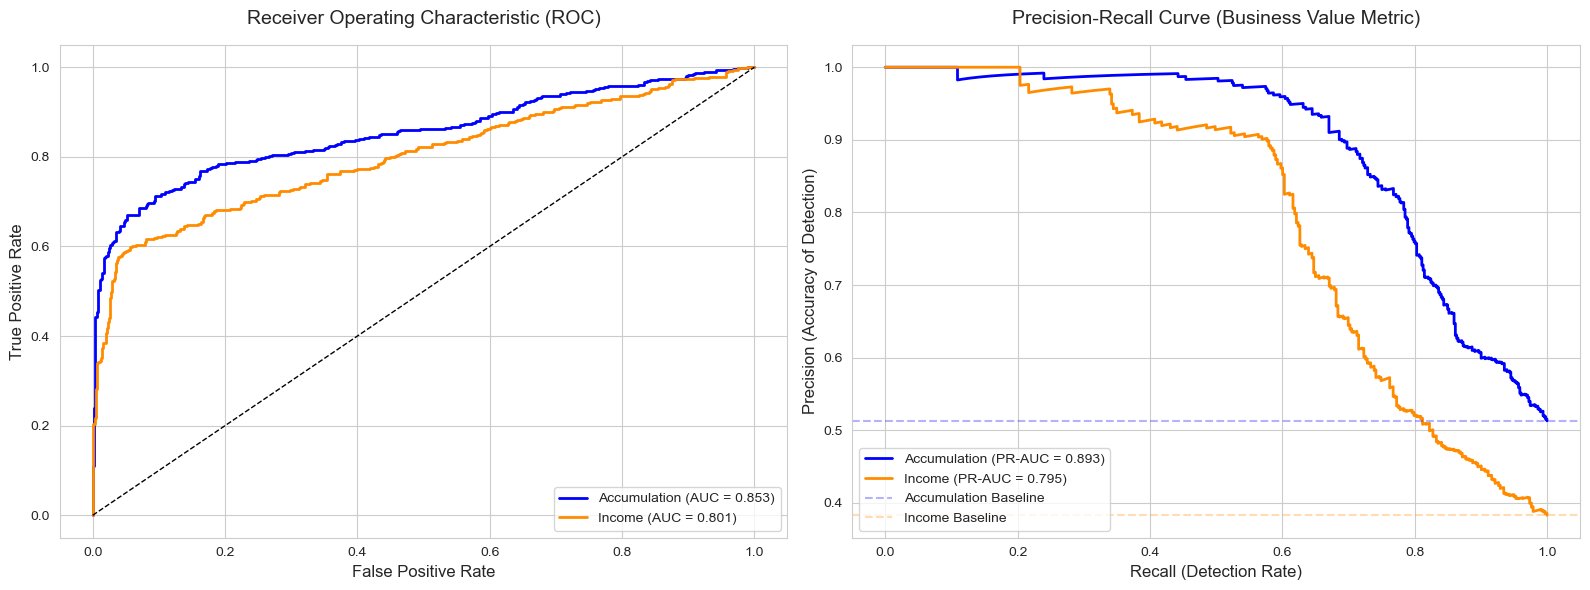

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, precision_recall_curve, auc

print("--- VISUALIZING MULTI-TASK MODEL PERFORMANCE ---\n")

# Set aesthetic style
sns.set_style("whitegrid")

def plot_model_curves(y_true_acc, y_prob_acc, y_true_inc, y_prob_inc):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # --- 1. ROC Curve ---
    fpr_acc, tpr_acc, _ = roc_curve(y_true_acc, y_prob_acc)
    fpr_inc, tpr_inc, _ = roc_curve(y_true_inc, y_prob_inc)
    
    axes[0].plot(fpr_acc, tpr_acc, label=f'Accumulation (AUC = {auc(fpr_acc, tpr_acc):.3f})', color='blue', lw=2)
    axes[0].plot(fpr_inc, tpr_inc, label=f'Income (AUC = {auc(fpr_inc, tpr_inc):.3f})', color='darkorange', lw=2)
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, pad=15)
    axes[0].set_xlabel('False Positive Rate', fontsize=12)
    axes[0].set_ylabel('True Positive Rate', fontsize=12)
    axes[0].legend(loc='lower right', frameon=True)
    
    # --- 2. Precision-Recall Curve ---
    # PR Curves are much more important for imbalanced targets (like the Income class)
    prec_acc, rec_acc, _ = precision_recall_curve(y_true_acc, y_prob_acc)
    prec_inc, rec_inc, _ = precision_recall_curve(y_true_inc, y_prob_inc)
    
    # Calculate baseline (random guessing) for PR curves
    baseline_acc = sum(y_true_acc) / len(y_true_acc)
    baseline_inc = sum(y_true_inc) / len(y_true_inc)
    
    axes[1].plot(rec_acc, prec_acc, label=f'Accumulation (PR-AUC = {auc(rec_acc, prec_acc):.3f})', color='blue', lw=2)
    axes[1].plot(rec_inc, prec_inc, label=f'Income (PR-AUC = {auc(rec_inc, prec_inc):.3f})', color='darkorange', lw=2)
    axes[1].axhline(y=baseline_acc, color='blue', linestyle='--', alpha=0.3, label='Accumulation Baseline')
    axes[1].axhline(y=baseline_inc, color='darkorange', linestyle='--', alpha=0.3, label='Income Baseline')
    axes[1].set_title('Precision-Recall Curve (Business Value Metric)', fontsize=14, pad=15)
    axes[1].set_xlabel('Recall (Detection Rate)', fontsize=12)
    axes[1].set_ylabel('Precision (Accuracy of Detection)', fontsize=12)
    axes[1].legend(loc='lower left', frameon=True)
    
    plt.tight_layout()
    plt.show()

# Assuming val_targs_acc and val_preds_acc were saved from your validation loop in Cell 4
# We use the raw probabilities for the curves
plot_model_curves(val_targs_acc, val_preds_acc, val_targs_inc, val_preds_inc)